In [41]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
from cameras.Ximea import XimeaCamera

In [118]:
def mean_capture(camera, n, roi=None):
    first_image = camera.capture(roi=roi)
    buffer = np.empty((n, *first_image.shape), dtype=first_image.dtype)
    buffer[0] = first_image
    for i in range(1, n):
        buffer[i] = camera.capture(roi=roi)
    return np.mean(buffer, axis=0).astype(first_image.dtype)

In [229]:
def optimize_exposure(camera, initial_exposure, min_exposure, max_exposure, alpha=1.05, ncycles=20, nmean=10, threshold=50, nbins=20, roi=None):
    exposure = np.clip(initial_exposure, min_exposure, max_exposure)

    for i in range(ncycles):
        camera.set_exposure(exposure)
        x = mean_capture(camera, nmean, roi=roi)
        x = x[x>threshold]
        counts, _ = np.histogram(x, bins=nbins, range=(threshold, 255))

        signal = 1 - counts[-1] / max(counts[-2], 1)

        exposure = np.clip(exposure * (alpha ** signal), min_exposure, max_exposure)

    return exposure

In [42]:
camera = XimeaCamera()

In [231]:
exposure = optimize_exposure(camera, 100, 15, 1000)
exposure

np.float64(56.204159277380064)

In [2]:
with h5py.File("results/test/data.h5") as f:
    images_phase_fourier = f["images_phase_fourier"][:]

1.6341463414634145


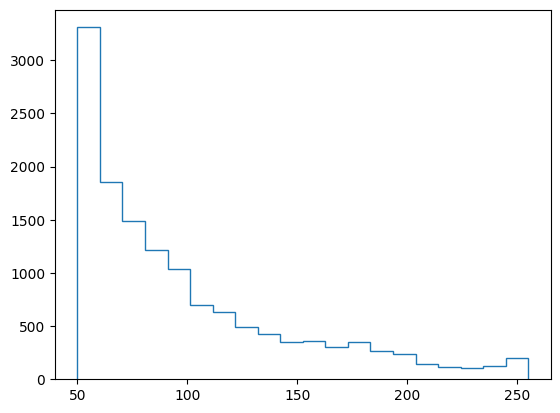

In [232]:
# x = images_phase_fourier[0, 0, 0, ...]
camera.set_exposure(exposure)
x = mean_capture(camera, 10)
counts, bins = np.histogram(x, bins=20, range=(50, 255))
plt.stairs(counts, bins)

print(counts[-1] / max(counts[-2], 1))

In [194]:
bins

array([  0, 225, 240, 255])

In [214]:
%timeit counts, bins = np.histogram(x[x>50], bins=20, range=(50, 255))

1.1 ms ± 34.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [50]:
bins

array([  0.  ,  12.75,  25.5 ,  38.25,  51.  ,  63.75,  76.5 ,  89.25,
       102.  , 114.75, 127.5 , 140.25, 153.  , 165.75, 178.5 , 191.25,
       204.  , 216.75, 229.5 , 242.25, 255.  ])

In [51]:
counts

array([   0,    0,    0,    0, 3712, 2098, 1617, 1163,  950,  699,  507,
        449,  402,  388,  399,  252,  178,  107,  106,  392])

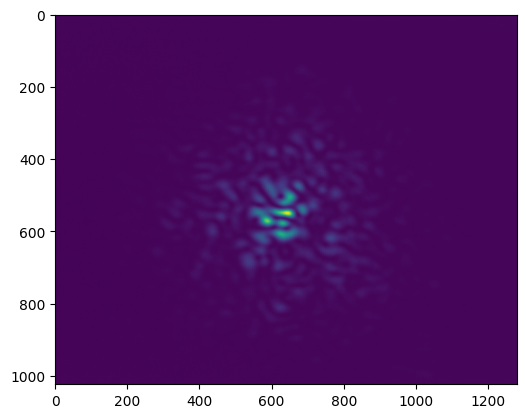

In [228]:
plt.imshow(camera.capture())